# Financial Transaction Fraud Risk Analysis (Python)
This notebook performs exploratory data analysis on credit card transactions to identify fraud patterns using Python, Pandas, and data visualization techniques.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

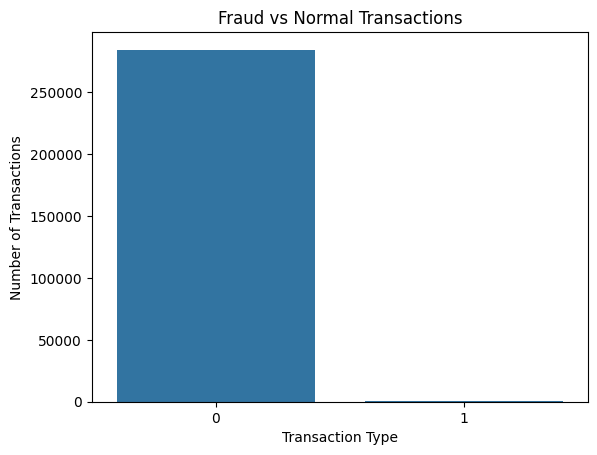

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

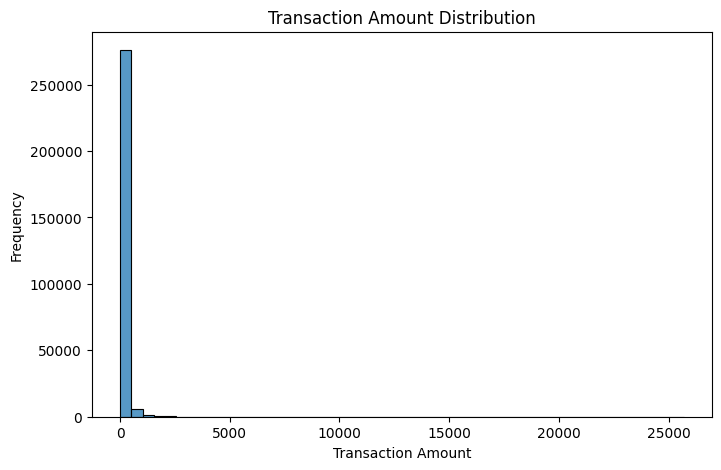

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

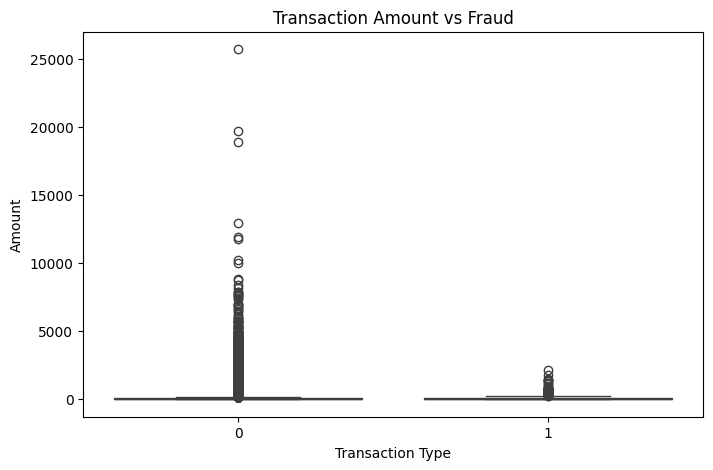

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.show()

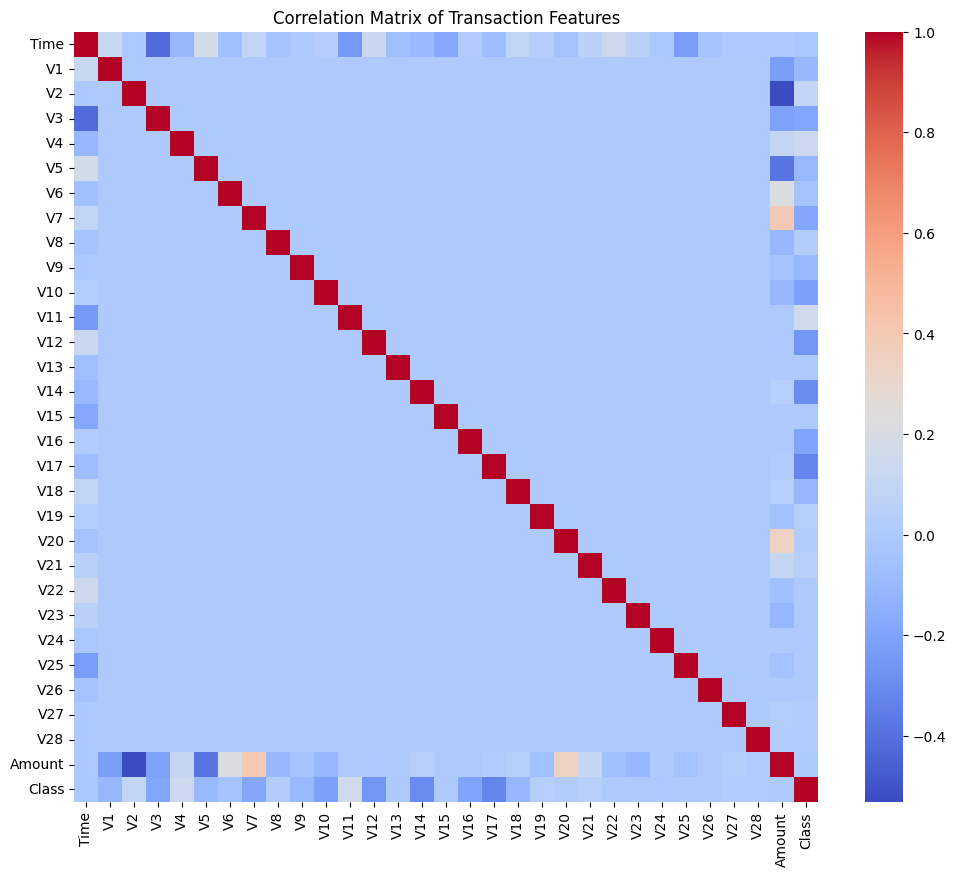

In [ ]:
plt.figure(figsize=(12,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix of Transaction Features")
plt.show()

In [ ]:
fraud_corr = df.corr()['Class'].sort_values(ascending=False)

print(fraud_corr)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


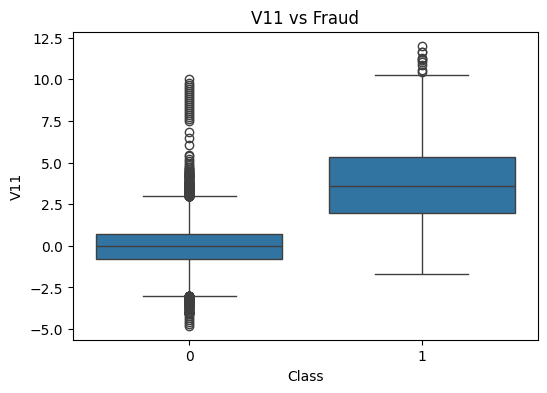

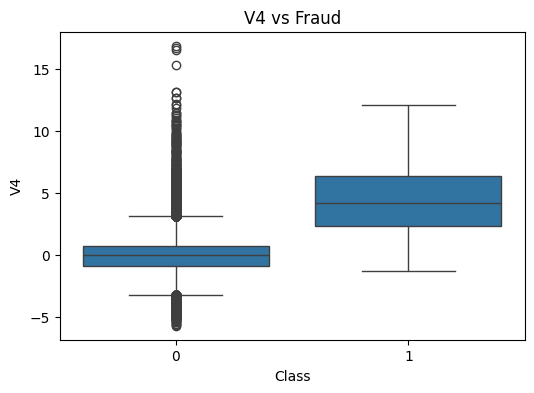

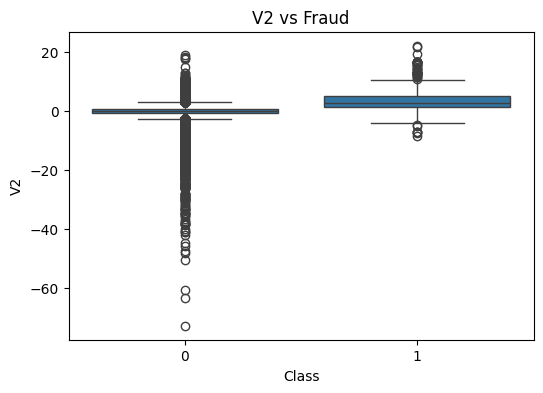

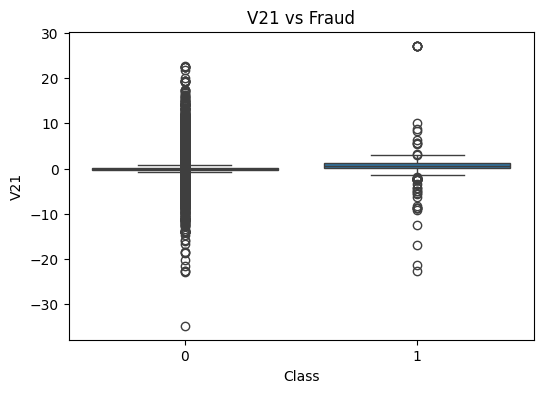

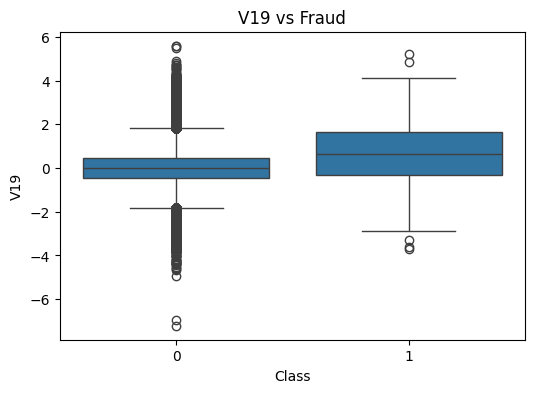

In [ ]:
top_features = fraud_corr.index[1:6]
for feature in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class', y=feature, data=df)
    plt.title(f"{feature} vs Fraud")
    plt.show()

## Key Insights from Fraud Analysis

1. Fraud transactions represent a very small portion of the dataset (approximately 0.17%), indicating a highly imbalanced dataset.

2. Transaction amount analysis shows that most transactions are small-value payments, with large transactions occurring less frequently.

3. Fraud probability analysis indicates that smaller transactions have slightly higher fraud percentages, which may reflect fraudsters testing stolen cards with small payments.

4. Correlation analysis reveals that several anonymized features (such as V14, V17, and V12) show stronger relationships with fraudulent activity.

5. Feature distribution comparisons suggest that fraudulent transactions follow different patterns compared to normal transactions, which can be useful for fraud detection modeling.

This analysis demonstrates how exploratory data analysis can reveal transaction risk patterns before building machine learning fraud detection models.